In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import cobra
import os
import sys
from os.path import join
from cobra.util import create_stoichiometric_matrix
from cobra.util.solver import linear_reaction_coefficients
from cobra.io import read_sbml_model, write_sbml_model
from cobra.flux_analysis import pfba
from time import sleep
from cobra.flux_analysis import flux_variability_analysis
sys.path.append(r"C:\Users\sacin\Downloads")
from efflux_method import *

data_dir = (r"C:\Users\sacin\Downloads")

model = cobra.io.read_sbml_model(join(r"C:\Users\sacin\Downloads\Mitomammal_model_10.sbml"))
list_of_genes=[]
for gene in model.genes:
    list_of_genes.append(gene.id)

In [126]:
l=[]
for reaction in result_UL_cyto[0].reactions:
    if reaction.upper_bound > 750 :
        l.append(reaction.id)
print(l)        

['EX_2hb_e', 'EX_ac_e', 'EX_acac_e', 'EX_akg_e', 'EX_ala_B_e', 'EX_ala_L_e', 'EX_arg_L_e', 'EX_argsuc_e', 'EX_asn_L_e', 'EX_asp_L_e', 'EX_bhb_e', 'EX_bilirub_e', 'EX_biomass_e', 'EX_but_e', 'EX_chol_e', 'EX_cit_e', 'EX_citr_L_e', 'EX_co_e', 'EX_co2_e', 'EX_creat_e', 'EX_cyan_e', 'EX_cys_L_e', 'EX_etoh_e', 'EX_fe2_e', 'EX_for_e', 'EX_fum_e', 'EX_glc_D_e', 'EX_gln_L_e', 'EX_glu_L_e', 'EX_gly_e', 'EX_glyc_e', 'EX_h_e', 'EX_h2o_e', 'EX_HC00250_e', 'EX_hco3_e', 'EX_hdca_e', 'EX_his_L_e', 'EX_icit_e', 'EX_ile_L_e', 'EX_lac_L_e', 'EX_leu_L_e', 'EX_lys_L_e', 'EX_mal_L_e', 'EX_mercplac_e', 'EX_met_L_e', 'EX_nad_e', 'EX_nadh_e', 'EX_nh4_e', 'EX_no_e', 'EX_o2_e', 'EX_oaa_e', 'EX_pchol_hs_e', 'EX_pcreat_e', 'EX_pe_hs_e', 'EX_phe_L_e', 'EX_pi_e', 'EX_ppa_e', 'EX_pro_L_e', 'EX_ps_hs_e', 'EX_ser_L_e', 'EX_so3_e', 'EX_succ_e', 'EX_tcynt_e', 'EX_thr_L_e', 'EX_trp_L_e', 'EX_tsul_e', 'EX_tyr_L_e', 'EX_urea_e', 'EX_val_L_e', 'EX_fol_e', 'OF_ATP_mitoMap', 'OF_HEME_mitoMap', 'OF_LIPID_mitoMap', 'OF_PROTEIN_

'SUCOASm', 'ASPTAm', 'GLUDxm', 'CV_mitoMap'

 'OF_ATP_mitoMap', 'OF_HEME_mitoMap', 'OF_LIPID_mitoMap', 'OF_PROTEIN_mitoMap', 'G6PPer', 'GAPD', 'PYK', 'r0122', 'G6PDH2r', 'NDPK1', 'r1155', 'METAT2_mitoMap', '3SPYRSP', 'r0645', 'AMCOXO', 'AMCOXO2_mitoMap', 'LYSOXc_mitoMap', 'PPD2CSPc_mitoMap', '1PPDCRc_mitoMap', '1PPDCRc_NADPH_mitoMap', 'RE1254C', 'G5SADrm', '4aabutn_mitoMap', '4ABUTtm', 'FTHFLm', 'AOBUTDsm', 'CKc', 'CK', 'ACALDtm', 'ADSS', '5AOPtm', 'PHEMEtm', 'GLYC3Ptm', 'ATPtmB_mitoMap', 'ACACt2mB_mitoMap', 'ASNtm', 'r1437', 'GLNtm', 'PROtm', 'r1078', 'r1436', 'r1455', 'TRPtm_mitoMap', 'GLYtm', 'ILEt5m', 'LEUt5m', 'VALt5m', 'r1434', 'r1435', 'r1440', 'BALAtmr', 'UREAtm', 'FUMtmB_mitoMap', 'BHBtmB_mitoMap', 'PPAtmB_mitoMap', 'BUTt2mB_mitoMap', 'FORt2mB_mitoMap', 'r0962B_mitoMap', 'CHLtmB_mitoMap', 'CO2tm', 'H2Otm', 'O2tm', 'GLYCtm', 'CYANtm', 'TCYNTtmB_mitoMap', 'CREATtmdiffir', 'PCREATtmdiffirB_mitoMap', 'r0941', 'r0838B_mitoMap', 'Biomasst_mitoMap', 'Biomass_mitoMap', 'CO2t', 'HCO3t_mitoMap', 'HDCAtr', 'HDCAtm_mitoMap', 'L_LACt2r', 'BHBt', 'ACACt2', 'ETOHt', 'BUTt2r', 'GLYCt', 'r0942', 'r0942b_mitoMap', 'HIStiDF', 'ILEtec', 'LEUtec', 'LYStiDF', 'METtec', 'PHEtec', 'r2534', 'TRPt', 'VALtec', 'ARGtiDF', 'ASPte', 'CYStec', 'GLUt_mitoMap', 'r2525', 'GLYt2r', 'PROt2r', 'r2526', 'TYRt', 'r2532', 'ALAt2r', 'FUMt_mitoMap', 'SUMt_mitoMap', 'r0817', 'NH4t3r', 'ACt2r', 'PPAt', '2HBt2', 'CHOLtu', 'r1088', 'ICITt_mitoMap', 'UREAt', 'r1512', 'ARGSUCt_mitoMap', 'MAL_Lte', 'OAAt_mitoMap', 'AKGt_mitoMap', 'MERCPLACt_mitoMap', 'r0899', 'FE2t', 'H2Ot', 'Hct_mitoMap', 'Hmt_mitoMap', 'SO3t_mitoMap', 'TSULt_mitoMap', 'r0940', 'CYANt', 'TCYNTt', 'r1423', 'FORt_mitoMap', 'FOLt_mitoMap', 'NADHt_mitoMap', 'NADt_mitoMap', 'NADHtm_mitoMap', 'NADtm_mitoMap', 'COt', 'NOt', 'PCHOLHSTDe', 'PSt3', 'PEt', 'DM_orot_c', 'CII'

In [124]:
k= 'OF_ATP_mitoMap', 'OF_HEME_mitoMap', 'OF_LIPID_mitoMap', 'OF_PROTEIN_mitoMap', 'G6PPer', 'GAPD', 'PYK', 'r0122', 'G6PDH2r', 'NDPK1', 'r1155', 'METAT2_mitoMap', '3SPYRSP', 'r0645', 'AMCOXO', 'AMCOXO2_mitoMap', 'LYSOXc_mitoMap', 'PPD2CSPc_mitoMap', '1PPDCRc_mitoMap', '1PPDCRc_NADPH_mitoMap', 'RE1254C', 'G5SADrm', '4aabutn_mitoMap', '4ABUTtm', 'FTHFLm', 'AOBUTDsm', 'CKc', 'CK', 'ACALDtm', 'ADSS', '5AOPtm', 'PHEMEtm', 'GLYC3Ptm', 'ATPtmB_mitoMap', 'ACACt2mB_mitoMap', 'ASNtm', 'r1437', 'GLNtm', 'PROtm', 'r1078', 'r1436', 'r1455', 'TRPtm_mitoMap', 'GLYtm', 'ILEt5m', 'LEUt5m', 'VALt5m', 'r1434', 'r1435', 'r1440', 'BALAtmr', 'UREAtm', 'FUMtmB_mitoMap', 'BHBtmB_mitoMap', 'PPAtmB_mitoMap', 'BUTt2mB_mitoMap', 'FORt2mB_mitoMap', 'r0962B_mitoMap', 'CHLtmB_mitoMap', 'CO2tm', 'H2Otm', 'O2tm', 'GLYCtm', 'CYANtm', 'TCYNTtmB_mitoMap', 'CREATtmdiffir', 'PCREATtmdiffirB_mitoMap', 'r0941', 'r0838B_mitoMap', 'Biomasst_mitoMap', 'Biomass_mitoMap', 'CO2t', 'HCO3t_mitoMap', 'HDCAtr', 'HDCAtm_mitoMap', 'L_LACt2r', 'BHBt', 'ACACt2', 'ETOHt', 'BUTt2r', 'GLYCt', 'r0942', 'r0942b_mitoMap', 'HIStiDF', 'ILEtec', 'LEUtec', 'LYStiDF', 'METtec', 'PHEtec', 'r2534', 'TRPt', 'VALtec', 'ARGtiDF', 'ASPte', 'CYStec', 'GLUt_mitoMap', 'r2525', 'GLYt2r', 'PROt2r', 'r2526', 'TYRt', 'r2532', 'ALAt2r', 'FUMt_mitoMap', 'SUMt_mitoMap', 'r0817', 'NH4t3r', 'ACt2r', 'PPAt', '2HBt2', 'CHOLtu', 'r1088', 'ICITt_mitoMap', 'UREAt', 'r1512', 'ARGSUCt_mitoMap', 'MAL_Lte', 'OAAt_mitoMap', 'AKGt_mitoMap', 'MERCPLACt_mitoMap', 'r0899', 'FE2t', 'H2Ot', 'Hct_mitoMap', 'Hmt_mitoMap', 'SO3t_mitoMap', 'TSULt_mitoMap', 'r0940', 'CYANt', 'TCYNTt', 'r1423', 'FORt_mitoMap', 'FOLt_mitoMap', 'NADHt_mitoMap', 'NADt_mitoMap', 'NADHtm_mitoMap', 'NADtm_mitoMap', 'COt', 'NOt', 'PCHOLHSTDe', 'PSt3', 'PEt', 'DM_orot_c', 'CII'
for reaction in k:
    rcn = result_UL_cyto[0].reactions.get_by_id(reaction)
    if str(rcn.gpr) == "" or str(rcn.gpr) == "Unknown":
        continue
    
    if rxn.reversibility:
       print(f"'{reaction}' : -1", f"{result_UL_cyto[0].reactions.get_by_id(reaction).bounds }" + f"{result_UL_cyto[0].reactions.get_by_id(reaction).name}")
    else:
        print(f"'{reaction}' : 1", f"{result_UL_cyto[0].reactions.get_by_id(reaction).bounds }"+ f"{result_UL_cyto[0].reactions.get_by_id(reaction).name}")
    
    

'G6PPer' : -1 (0, 1000.0)R_G6PPer alpha-D-Glucose 6-phosphate + H2O --> alpha-D-Glucose + Orthophosphate
'GAPD' : -1 (-1000.0, 1000.0)R_GAPD D-Glyceraldehyde 3-phosphate + Orthophosphate + NAD+ --> 3-Phospho-D-glyceroyl phosphate + NADH + H+
'PYK' : -1 (0, 1000.0)R_PYK ADP + Phosphoenolpyruvate --> ATP + Pyruvate
'r0122' : -1 (0, 1000.0)R_r0122  GDP + Phosphoenolpyruvate --> GTP + Pyruvate
'G6PDH2r' : -1 (0, 1000.0)R_G6PDH2r beta-D-Glucose 6-phosphate + NADP+ --> D-Glucono-1,5-lactone 6-phosphate + NADPH + H+
'NDPK1' : -1 (-1536.1499232103076, 1536.1499232103076)R_NDPK1 ATP + GDP --> ADP + GTP
'METAT2_mitoMap' : -1 (0, 1000.0)R_METAT2_mitoMap S-Adenosyl-L-methionine + demethylated methyl donor --> S-Adenosyl-L-homocysteine + methyl donor
'3SPYRSP' : -1 (-1000.0, 1000.0)R_3SPYRSP 3-Sulfinylpyruvate + H2O --> Sulfite + Pyruvate
'PPD2CSPc_mitoMap' : -1 (-1000.0, 1000.0)R_PPD2CSPc_mitoMap 6-Amino-2-oxohexanoate --> delta1-Piperideine-2-carboxylate + H2O
'G5SADrm' : -1 (-1000.0, 1000.0)R_G5

In [95]:
k= 'OF_ATP_mitoMap', 'OF_HEME_mitoMap', 'OF_LIPID_mitoMap', 'OF_PROTEIN_mitoMap', 'G6PPer', 'GAPD', 'PYK', 'r0122', 'G6PDH2r', 'NDPK1', 'r1155', 'METAT2_mitoMap', '3SPYRSP', 'r0645', 'AMCOXO', 'AMCOXO2_mitoMap', 'LYSOXc_mitoMap', 'PPD2CSPc_mitoMap', '1PPDCRc_mitoMap', '1PPDCRc_NADPH_mitoMap', 'RE1254C', 'G5SADrm', '4aabutn_mitoMap', '4ABUTtm', 'FTHFLm', 'AOBUTDsm', 'CKc', 'CK', 'ACALDtm', 'ADSS', '5AOPtm', 'PHEMEtm', 'GLYC3Ptm', 'ATPtmB_mitoMap', 'ACACt2mB_mitoMap', 'ASNtm', 'r1437', 'GLNtm', 'PROtm', 'r1078', 'r1436', 'r1455', 'TRPtm_mitoMap', 'GLYtm', 'ILEt5m', 'LEUt5m', 'VALt5m', 'r1434', 'r1435', 'r1440', 'BALAtmr', 'UREAtm', 'FUMtmB_mitoMap', 'BHBtmB_mitoMap', 'PPAtmB_mitoMap', 'BUTt2mB_mitoMap', 'FORt2mB_mitoMap', 'r0962B_mitoMap', 'CHLtmB_mitoMap', 'CO2tm', 'H2Otm', 'O2tm', 'GLYCtm', 'CYANtm', 'TCYNTtmB_mitoMap', 'CREATtmdiffir', 'PCREATtmdiffirB_mitoMap', 'r0941', 'r0838B_mitoMap', 'Biomasst_mitoMap', 'Biomass_mitoMap', 'CO2t', 'HCO3t_mitoMap', 'HDCAtr', 'HDCAtm_mitoMap', 'L_LACt2r', 'BHBt', 'ACACt2', 'ETOHt', 'BUTt2r', 'GLYCt', 'r0942', 'r0942b_mitoMap', 'HIStiDF', 'ILEtec', 'LEUtec', 'LYStiDF', 'METtec', 'PHEtec', 'r2534', 'TRPt', 'VALtec', 'ARGtiDF', 'ASPte', 'CYStec', 'GLUt_mitoMap', 'r2525', 'GLYt2r', 'PROt2r', 'r2526', 'TYRt', 'r2532', 'ALAt2r', 'FUMt_mitoMap', 'SUMt_mitoMap', 'r0817', 'NH4t3r', 'ACt2r', 'PPAt', '2HBt2', 'CHOLtu', 'r1088', 'ICITt_mitoMap', 'UREAt', 'r1512', 'ARGSUCt_mitoMap', 'MAL_Lte', 'OAAt_mitoMap', 'AKGt_mitoMap', 'MERCPLACt_mitoMap', 'r0899', 'FE2t', 'H2Ot', 'Hct_mitoMap', 'Hmt_mitoMap', 'SO3t_mitoMap', 'TSULt_mitoMap', 'r0940', 'CYANt', 'TCYNTt', 'r1423', 'FORt_mitoMap', 'FOLt_mitoMap', 'NADHt_mitoMap', 'NADt_mitoMap', 'NADHtm_mitoMap', 'NADtm_mitoMap', 'COt', 'NOt', 'PCHOLHSTDe', 'PSt3', 'PEt', 'DM_orot_c', 'CII'
for reaction in k:
    rcn = result_UL_cyto[0].reactions.get_by_id(reaction)
    if str(rcn.gpr) == "" or str(rcn.gpr) == "Unknown":
        continue
    
    print(f"'{reaction}',")
    
    

'G6PPer',
'GAPD',
'PYK',
'r0122',
'G6PDH2r',
'NDPK1',
'METAT2_mitoMap',
'3SPYRSP',
'PPD2CSPc_mitoMap',
'G5SADrm',
'FTHFLm',
'AOBUTDsm',
'CKc',
'CK',
'ACALDtm',
'ADSS',
'ATPtmB_mitoMap',
'ACACt2mB_mitoMap',
'BUTt2mB_mitoMap',
'CHLtmB_mitoMap',
'CII',


In [35]:
result_UL_cyto[1].fluxes

EX_2hb_e      1.739500e-14
EX_ac_e       0.000000e+00
EX_acac_e     0.000000e+00
EX_akg_e     -6.892793e+01
EX_ala_B_e   -6.186981e-15
                  ...     
DM_orot_c     0.000000e+00
CI            2.400000e+01
CII           0.000000e+00
CIII          2.400000e+01
CIV           1.200000e+01
Name: fluxes, Length: 560, dtype: float64

In [ ]:
threshold = 0.01

active_reactions = (solution.fluxes > threshold).sum()

t = len(result_UL_cyto[1].fluxes)

prcntg_active = (active_reactions / t) * 100
print(f"Active reactions: {active_reactions} / {t} = {prcntg_active}%")


Active reactions: 72 / 560 = 12.857142857142856%


In [5]:
list_of_reactions= ['G6PPer',
'GAPD',
'PYK',
'r0122',
'G6PDH2r',
'NDPK1',
'METAT2_mitoMap',
'3SPYRSP',
'PPD2CSPc_mitoMap',
'G5SADrm',
'FTHFLm',
'AOBUTDsm',
'CKc',
'CK',
'ACALDtm',
'ADSS',
'ATPtmB_mitoMap',
'ACACt2mB_mitoMap',
'BUTt2mB_mitoMap',
'CHLtmB_mitoMap',
'CII',]


threshold = 1e-20

active_reactions = (result_UL_cyto[1].fluxes[list_of_reactions] > threshold).sum()

t = len(list_of_reactions)

prcntg_active = (active_reactions / t) * 100

print(f"Active reactions: {active_reactions} / {t} = {prcntg_active}%")

   

Active reactions: 3 / 21 = 14.285714285714285%


In [6]:
threshold = 1e-20
mask = result_UL_cyto[1].fluxes[list_of_reactions] > threshold
active_reactions_list = mask[mask].index.tolist()

print("Active reactions:", active_reactions_list)
print(f"Count: {len(active_reactions_list)} / {len(list_of_reactions)}")

Active reactions: ['GAPD', 'PYK', 'ATPtmB_mitoMap']
Count: 3 / 21


In [ ]:
result_UL_cyto[0].reactions.get_by_id(reaction).flux

40.3738878269572

'SUCOASm', 'OF_ATP_mitoMap', 'GLUDxm', 'OF_PROTEIN_mitoMap'

In [2]:
def perform_FBA(file_path, id_gene, id_value, human, constant, objective_id, o2_upper_bound=None):
    """This function open the model, constrain it with Omics data (human or not) and optimise the model with the selected objective function
    args:
        file_path (str):
        id_gene (int): position of the gene identifier in the dataframe
        id_value (int): position of the value in the dataframe
        human (bool): constrain data on humain or mouse data
        constant (int): constant value used to scale the constrain (only to make the value easier for human)
        objective_id (id): identifier of the objective function in the model
        o2_upper_bound (float): optional oxygen upper bound constraint
    return:
        model (cobra.core.model): a constrained model
        pfba (cobra.Solution.solution): solution of parsimonious FBA
    """
    model = cobra.io.read_sbml_model(join(r"C:\Users\sacin\Downloads\Mitomammal_model_10.sbml"))
    list_of_genes = []
    for gene in model.genes:
        list_of_genes.append(gene.id)
    data_dictionary = read_csv_data(path=file_path,
                                    list_of_genes=list_of_genes,
                                    id_gene=id_gene,
                                    id_val=id_value,
                                    sep=",",
                                    quantile=0.95,
                            
                                    head=True)

    # neuron bounds
    model.reactions.get_by_id("CII").bounds = (0.0, 1000)
    model.reactions.get_by_id("GLCt1r").bounds = (-1000, 5.0)
    model.reactions.get_by_id("r0942").bounds = (-0.05, 1000)
    model.reactions.get_by_id("r0942b_mitoMap").bounds = (-0.05, 1000)
    model.reactions.get_by_id("CK").bounds = (0.0, 1000.0)
    model.reactions.get_by_id("CKc").bounds = (0.0, 1000.0)
    model.reactions.get_by_id("FTHFLm").bounds = (0.0, 1000.0)

    
    if o2_upper_bound is not None:
        model.reactions[478].upper_bound = o2_upper_bound
        model.reactions[478].lower_bound = 0

    model.objective = model.reactions[objective_id]
    Eflux(model, data_dictionary, constant, 1, ignore_human=not human, ignore_mus=human)       
    
    if o2_upper_bound is not None:
        model.reactions[478].upper_bound = o2_upper_bound
        model.reactions[478].lower_bound = 0
    # neuron bounds
    model.reactions.get_by_id("CII").bounds = (0.0, 1000)
    model.reactions.get_by_id("GLCt1r").bounds = (-1000, 5.0)
    model.reactions.get_by_id("r0942").bounds = (-0.05, 1000)
    model.reactions.get_by_id("r0942b_mitoMap").bounds = (-0.05, 1000)
    model.reactions.get_by_id("CK").bounds = (0.0, 1000.0)
    model.reactions.get_by_id("CKc").bounds = (0.0, 1000.0)
    model.reactions.get_by_id("FTHFLm").bounds = (0.0, 1000.0)
    exch, const = 0, 0
    for react in model.reactions:
        if react.bounds[1] == constant:
            const += 1
        elif react.bounds[1] == 1000:
            exch += 1

    return [model, pfba(model)]

In [14]:
def print_result(solution, label=""):
    print(f"\n--- {label} ---")
    print(f"Cytosolic ATP:   {solution.fluxes['OF_ATP_mitoMap']:.3f}")
    print(f"Mito ATP (CV):   {solution.fluxes['CV_mitoMap']:.3f}")
    print(f"Complex I:       {solution.fluxes['CI']:.3f}")
    print(f"Complex II:      {solution.fluxes['CII']:.3f}")
    print(f"Complex III:     {solution.fluxes['CIII']:.3f}")
    print(f"Complex IV:      {solution.fluxes['CIV']:.3f}")
    print(f"Complex V:       {solution.fluxes['CV_mitoMap']:.3f}")
    print(f"O2 transport:    {solution.fluxes['O2t']:.3f}")

print_result(result_AP_cyto[1], label="AP cytosolic ATP")


--- AP cytosolic ATP ---
Cytosolic ATP:   155.378
Mito ATP (CV):   28.357
Complex I:       6.000
Complex II:      0.000
Complex III:     6.000
Complex IV:      3.000
Complex V:       28.357
O2 transport:    3.000


In [ ]:
# Cytosolic ATP 
result_AP_cyto = perform_FBA(r"C:\Users\sacin\Downloads\mapped_AP_cycling_pseudobulk_normalized_sum.csv", 0, 7, False, constant=1000, objective_id=70, o2_upper_bound=3)
result_BP_cyto = perform_FBA(r"C:\Users\sacin\Downloads\mapped_BP_cycling_pseudobulk_normalized_sum.csv", 0, 7, False, 1000, 70, o2_upper_bound=6)
result_DL_cyto = perform_FBA(r"C:\Users\sacin\Downloads\mapped_DL_neurons_pseudobulk_normalized_sum.csv", 0, 7, False, 1000, 70, o2_upper_bound=9)
result_UL_cyto = perform_FBA(r"C:\Users\sacin\Downloads\mapped_UL_differentiating_pseudobulk_normalized_sum.csv", 0, 7, False, 1000, 70, o2_upper_bound=12)

# Mitochondrial ATP 
result_AP_mito = perform_FBA(r"C:\Users\sacin\Downloads\mapped_AP_cycling_pseudobulk_normalized_sum.csv", 0, 7, False, 1000, 415, o2_upper_bound=3)
result_BP_mito = perform_FBA(r"C:\Users\sacin\Downloads\mapped_BP_cycling_pseudobulk_normalized_sum.csv", 0, 7, False, 1000, 415, o2_upper_bound=6)
result_DL_mito = perform_FBA(r"C:\Users\sacin\Downloads\mapped_DL_neurons_pseudobulk_normalized_sum.csv", 0, 7, False, 1000, 415, o2_upper_bound=9)
result_UL_mito = perform_FBA(r"C:\Users\sacin\Downloads\mapped_UL_differentiating_pseudobulk_normalized_sum.csv", 0, 7, False, 1000, 415, o2_upper_bound=12)

In [7]:
ul_expression = pd.read_csv(r"C:\Users\sacin\Downloads\mapped_UL_differentiating_pseudobulk_normalized_sum.csv", index_col=0)

for reaction in k:
    rxn = result_UL_cyto[0].reactions.get_by_id(reaction)
    genes = rxn.genes
    
    print(f"\n{reaction}: {rxn.name}")
    for gene in genes:
        if gene.id in ul_expression.index:
            expr = ul_expression.loc[gene.id, ul_expression.columns[0]]
            print(f"  {gene.id}: {expr:.4f}")


OF_ATP_mitoMap: R_OF_ATP_mitoMap Maximum ATP production (ATP hydrolysis)

OF_HEME_mitoMap: R_OF_HEME_mitoMap Maximum Heme production

OF_LIPID_mitoMap: R_OF_LIPID_mitoMap Maximum lipid synthesis (Mito Inner Membrane)

OF_PROTEIN_mitoMap: R_OF_PROTEIN_mitoMap Maxmium production of amino acids for protein synthesis

G6PPer: R_G6PPer alpha-D-Glucose 6-phosphate + H2O --> alpha-D-Glucose + Orthophosphate

GAPD: R_GAPD D-Glyceraldehyde 3-phosphate + Orthophosphate + NAD+ --> 3-Phospho-D-glyceroyl phosphate + NADH + H+


ValueError: Unknown format code 'f' for object of type 'str'

In [30]:
for reaction in model.reactions:
    print(f"bounds of {reaction}" "is",f"{sorted(reaction.bounds)}" )


bounds of EX_2hb_e: 2hb_e <=> is [-1000.0, 1000.0]
bounds of EX_ac_e: ac_e <=> is [-1000.0, 1000.0]
bounds of EX_acac_e: acac_e <=> is [-1000.0, 1000.0]
bounds of EX_akg_e: akg_e <=> is [-1000.0, 1000.0]
bounds of EX_ala_B_e: ala_B_e <=> is [-1000.0, 1000.0]
bounds of EX_ala_L_e: ala_L_e <=> is [-1000.0, 1000.0]
bounds of EX_arg_L_e: arg_L_e <=> is [-1000.0, 1000.0]
bounds of EX_argsuc_e: argsuc_e <=> is [-1000.0, 1000.0]
bounds of EX_asn_L_e: asn_L_e <=> is [-1000.0, 1000.0]
bounds of EX_asp_L_e: asp_L_e <=> is [-1000.0, 1000.0]
bounds of EX_bhb_e: bhb_e <=> is [-1000.0, 1000.0]
bounds of EX_bilirub_e: bilirub_e <=> is [-1000.0, 1000.0]
bounds of EX_biomass_e: biomass_e <=> is [-inf, inf]
bounds of EX_but_e: but_e <=> is [-1000.0, 1000.0]
bounds of EX_chol_e: chol_e <=> is [-1000.0, 1000.0]
bounds of EX_cit_e: cit_e <=> is [-1000.0, 1000.0]
bounds of EX_citr_L_e: citr_L_e <=> is [-1000.0, 1000.0]
bounds of EX_co_e: co_e <=> is [-1000.0, 1000.0]
bounds of EX_co2_e: co2_e <=> is [-1000.

In [ ]:
print("AP cyto bounds")
print(result_AP_cyto[0].reactions.get_by_id("CI").bounds)
print(result_AP_cyto[0].reactions.get_by_id("CII").bounds)
print(result_AP_cyto[0].reactions.get_by_id("CIII").bounds)
print(result_AP_cyto[0].reactions.get_by_id("CIV").bounds)
print(result_AP_cyto[0].reactions.get_by_id("CV_mitoMap").bounds)

print("BP cyto bounds")
print(result_BP_cyto[0].reactions.get_by_id("CI").bounds)
print(result_BP_cyto[0].reactions.get_by_id("CII").bounds)
print(result_BP_cyto[0].reactions.get_by_id("CIII").bounds)
print(result_BP_cyto[0].reactions.get_by_id("CIV").bounds)
print(result_BP_cyto[0].reactions.get_by_id("CV_mitoMap").bounds)

print("DL cyto bounds")
print(result_DL_cyto[0].reactions.get_by_id("CI").bounds)
print(result_DL_cyto[0].reactions.get_by_id("CII").bounds)
print(result_DL_cyto[0].reactions.get_by_id("CIII").bounds)
print(result_DL_cyto[0].reactions.get_by_id("CIV").bounds)
print(result_DL_cyto[0].reactions.get_by_id("CV_mitoMap").bounds)

print("UL cyto bounds")
print(result_UL_cyto[0].reactions.get_by_id("CI").bounds)
print(result_UL_cyto[0].reactions.get_by_id("CII").bounds)
print(result_UL_cyto[0].reactions.get_by_id("CIII").bounds)
print(result_UL_cyto[0].reactions.get_by_id("CIV").bounds)
print(result_UL_cyto[0].reactions.get_by_id("CV_mitoMap").bounds)

AP cyto bounds
(-55.25889181950391, 55.25889181950391)
(0.0, 1000)
(-136.7699882132516, 136.7699882132516)
(-550.1689755610607, 550.1689755610607)
(-106.83568131579162, 106.83568131579162)
BP cyto bounds
(-53.16366959056064, 53.16366959056064)
(0.0, 1000)
(-102.49366813759647, 102.49366813759647)
(-575.8287509453894, 575.8287509453894)
(-93.02936674212857, 93.02936674212857)
DL cyto bounds
(-56.09541831289148, 56.09541831289148)
(0.0, 1000)
(-205.5984060409383, 205.5984060409383)
(-672.1338036199166, 672.1338036199166)
(-144.17679195842382, 144.17679195842382)
UL cyto bounds
(-62.041186698881184, 62.041186698881184)
(0.0, 1000)
(-180.3897891098307, 180.3897891098307)
(-627.6261364520898, 627.6261364520898)
(-136.61723771598645, 136.61723771598645)


In [ ]:
print("Oxygen bounds per cell type:")
print("AP:", result_AP_cyto[0].reactions[478].bounds)
print("BP:", result_BP_cyto[0].reactions[478].bounds)
print("DL:", result_DL_cyto[0].reactions[478].bounds)
print("UL:", result_UL_cyto[0].reactions[478].bounds)

Oxygen bounds per cell type:
AP: (0, 3)
BP: (0, 6)
DL: (0, 9)
UL: (0, 12)


In [ ]:
def print_result(solution, label=""):
    print(f"\n--- {label} ---")
    print(f"Cytosolic ATP:   {solution.fluxes['OF_ATP_mitoMap'] - solution.fluxes['ATPtmB_mitoMap']:.3f}")
    print(f"Mito ATP (CV):   {solution.fluxes['ATPtmB_mitoMap']:.3f}")
    print(f"Complex I:       {solution.fluxes['CI']:.3f}")
    print(f"Complex II:      {solution.fluxes['CII']:.3f}")
    print(f"Complex III:     {solution.fluxes['CIII']:.3f}")
    print(f"Complex IV:      {solution.fluxes['CIV']:.3f}")
    print(f"Complex V:       {solution.fluxes['CV_mitoMap']:.3f}")
    print(f"O2 transport:    {solution.fluxes['O2t']:.3f}")

print_result(result_AP_cyto[1], label="AP cytosolic ATP")
print_result(result_BP_cyto[1], label="BP cytosolic ATP")
print_result(result_DL_cyto[1], label="DL cytosolic ATP")
print_result(result_UL_cyto[1], label="UL cytosolic ATP")
print_result(result_AP_mito[1], label="AP mitochondrial ATP")
print_result(result_BP_mito[1], label="BP mitochondrial ATP")
print_result(result_DL_mito[1], label="DL mitochondrial ATP")
print_result(result_UL_mito[1], label="UL mitochondrial ATP")


--- AP cytosolic ATP ---
Cytosolic ATP:   26.604
Mito ATP (CV):   128.774
Complex I:       6.000
Complex II:      0.000
Complex III:     6.000
Complex IV:      3.000
Complex V:       28.357
O2 transport:    3.000

--- BP cytosolic ATP ---
Cytosolic ATP:   34.336
Mito ATP (CV):   148.050
Complex I:       12.000
Complex II:      0.000
Complex III:     12.000
Complex IV:      6.000
Complex V:       50.588
O2 transport:    6.000

--- DL cytosolic ATP ---
Cytosolic ATP:   54.616
Mito ATP (CV):   95.908
Complex I:       18.000
Complex II:      0.000
Complex III:     18.000
Complex IV:      9.000
Complex V:       71.890
O2 transport:    9.000

--- UL cytosolic ATP ---
Cytosolic ATP:   40.374
Mito ATP (CV):   140.342
Complex I:       24.000
Complex II:      0.000
Complex III:     24.000
Complex IV:      12.000
Complex V:       93.878
O2 transport:    12.000

--- AP mitochondrial ATP ---
Cytosolic ATP:   -132.440
Mito ATP (CV):   132.440
Complex I:       6.000
Complex II:      0.000
Complex II

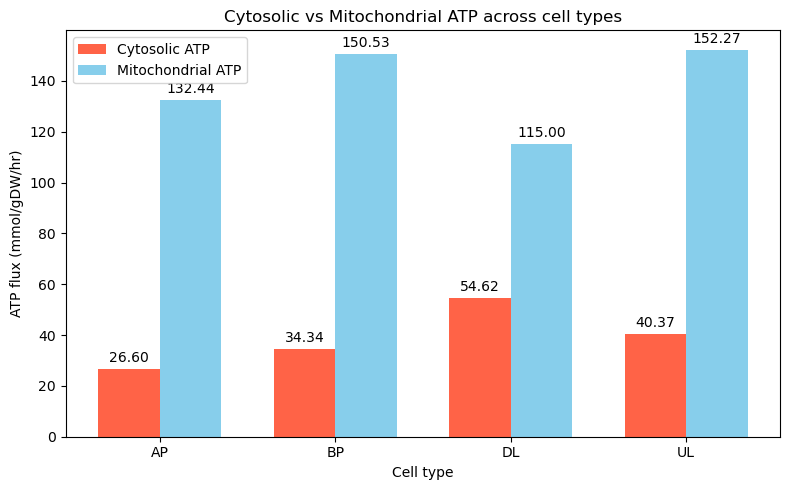

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cell_types = ["AP", "BP", "DL", "UL"]

cyto_atp = [
    result_AP_cyto[1].fluxes["OF_ATP_mitoMap"]- result_AP_cyto[1].fluxes["ATPtmB_mitoMap"],
    result_BP_cyto[1].fluxes["OF_ATP_mitoMap"]- result_BP_cyto[1].fluxes["ATPtmB_mitoMap"] ,
    result_DL_cyto[1].fluxes["OF_ATP_mitoMap"] - result_DL_cyto[1].fluxes["ATPtmB_mitoMap"],
    result_UL_cyto[1].fluxes["OF_ATP_mitoMap"]- result_UL_cyto[1].fluxes["ATPtmB_mitoMap"]
]

mito_atp = [
    result_AP_mito[1].fluxes["ATPtmB_mitoMap"],
    result_BP_mito[1].fluxes["ATPtmB_mitoMap"],
    result_DL_mito[1].fluxes["ATPtmB_mitoMap"],
    result_UL_mito[1].fluxes["ATPtmB_mitoMap"]
]

x = np.arange(len(cell_types))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, cyto_atp, width, label="Cytosolic ATP", color="tomato")
bars2 = ax.bar(x + width/2, mito_atp, width, label="Mitochondrial ATP", color="skyblue")

ax.set_xlabel("Cell type")
ax.set_ylabel("ATP flux (mmol/gDW/hr)")
ax.set_title("Cytosolic vs Mitochondrial ATP across cell types")
ax.set_xticks(x)
ax.set_xticklabels(cell_types)
ax.legend()

for b in bars1 + bars2:
    height = b.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(b.get_x() + b.get_width()/2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

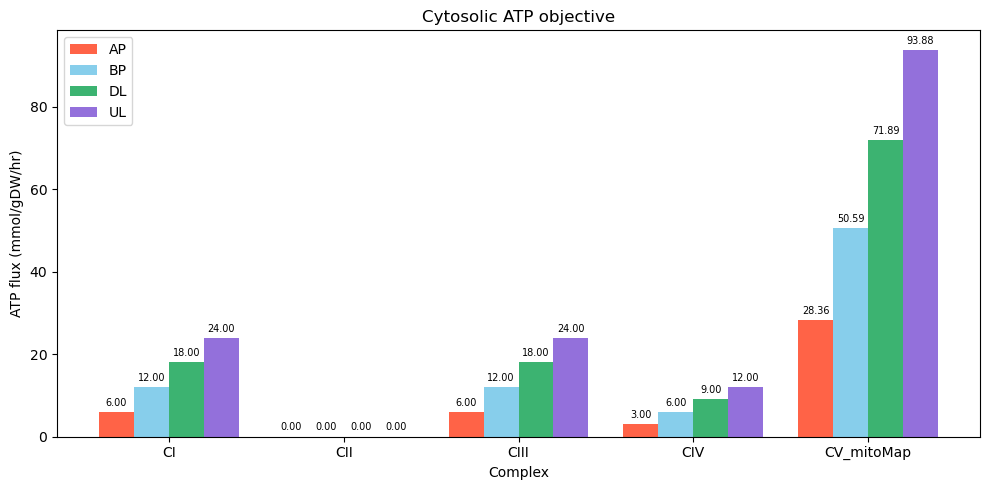

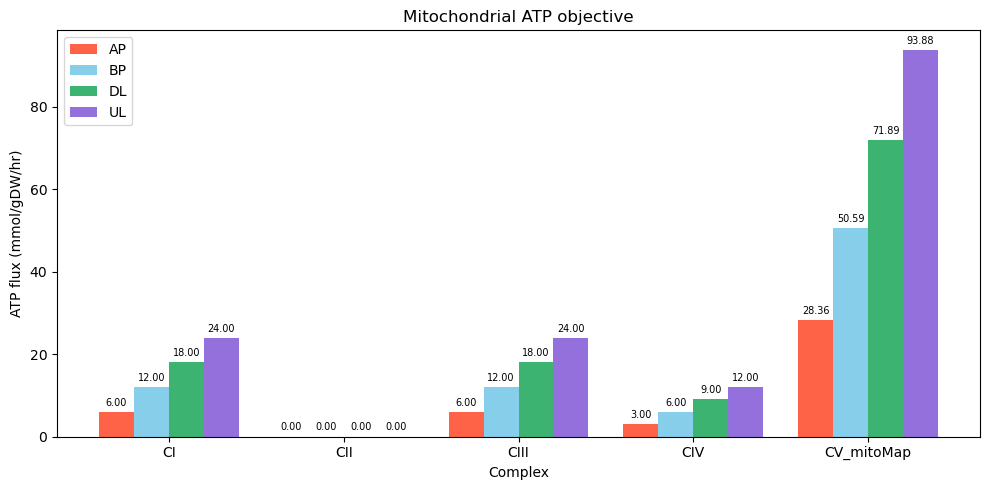

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cell_types = ["AP", "BP", "DL", "UL"]
complexes = ["CI", "CII", "CIII", "CIV", "CV_mitoMap"]

cyto_results = {
    "AP": result_AP_cyto[1],
    "BP": result_BP_cyto[1],
    "DL": result_DL_cyto[1],
    "UL": result_UL_cyto[1]
}

mito_results = {
    "AP": result_AP_mito[1],
    "BP": result_BP_mito[1],
    "DL": result_DL_mito[1],
    "UL": result_UL_mito[1]
}

colors = ["tomato", "skyblue", "mediumseagreen", "mediumpurple"]
x = np.arange(len(complexes))
width = 0.2

# plot 1 
fig, ax = plt.subplots(figsize=(10, 5))
for i, ct in enumerate(cell_types):
    fluxes = [cyto_results[ct].fluxes[c] for c in complexes]
    bars = ax.bar(x + i * width, fluxes, width, label=ct, color=colors[i])
    for b in bars:
        height = b.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(b.get_x() + b.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=7)

ax.set_xlabel("Complex")
ax.set_ylabel("ATP flux (mmol/gDW/hr)")
ax.set_title("Cytosolic ATP objective")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(complexes)
ax.legend()
plt.tight_layout()
plt.show()

# plot 2 
fig, ax = plt.subplots(figsize=(10, 5))
for i, ct in enumerate(cell_types):
    fluxes = [mito_results[ct].fluxes[c] for c in complexes]
    bars = ax.bar(x + i * width, fluxes, width, label=ct, color=colors[i])
    for b in bars:
        height = b.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(b.get_x() + b.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=7)

ax.set_xlabel("Complex")
ax.set_ylabel("ATP flux (mmol/gDW/hr)")
ax.set_title("Mitochondrial ATP objective")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(complexes)
ax.legend()
plt.tight_layout()
plt.show()


=== AP ===
O2 = 1 | CV = 13.5421
O2 = 2 | CV = 20.9495
O2 = 3 | CV = 28.3569
O2 = 4 | CV = 35.7643
O2 = 5 | CV = 43.1717
O2 = 6 | CV = 50.5791
O2 = 7 | CV = 57.9865
O2 = 8 | CV = 65.3939
O2 = 9 | CV = 72.8013
O2 = 10 | CV = 80.2087
O2 = 11 | CV = 87.6161
O2 = 12 | CV = 95.0235
O2 = 13 | CV = 102.4310
O2 = 14 | CV = 106.8357
O2 = 15 | CV = 106.8357
O2 = 16 | CV = 106.8357
O2 = 17 | CV = 106.8357
O2 = 18 | CV = 106.8357
O2 = 19 | CV = 106.8357

=== BP ===
O2 = 1 | CV = 13.5505
O2 = 2 | CV = 20.9579
O2 = 3 | CV = 28.3653
O2 = 4 | CV = 35.7727
O2 = 5 | CV = 43.1802
O2 = 6 | CV = 50.5876
O2 = 7 | CV = 57.9950
O2 = 8 | CV = 65.4024
O2 = 9 | CV = 72.8098
O2 = 10 | CV = 80.2172
O2 = 11 | CV = 87.6246
O2 = 12 | CV = 93.0294
O2 = 13 | CV = 93.0294
O2 = 14 | CV = 93.0294
O2 = 15 | CV = 93.0294
O2 = 16 | CV = 93.0294
O2 = 17 | CV = 93.0294
O2 = 18 | CV = 93.0294
O2 = 19 | CV = 93.0294

=== DL ===
O2 = 1 | CV = 12.6307
O2 = 2 | CV = 20.0381
O2 = 3 | CV = 27.4455
O2 = 4 | CV = 34.8530
O2 = 5 | CV =

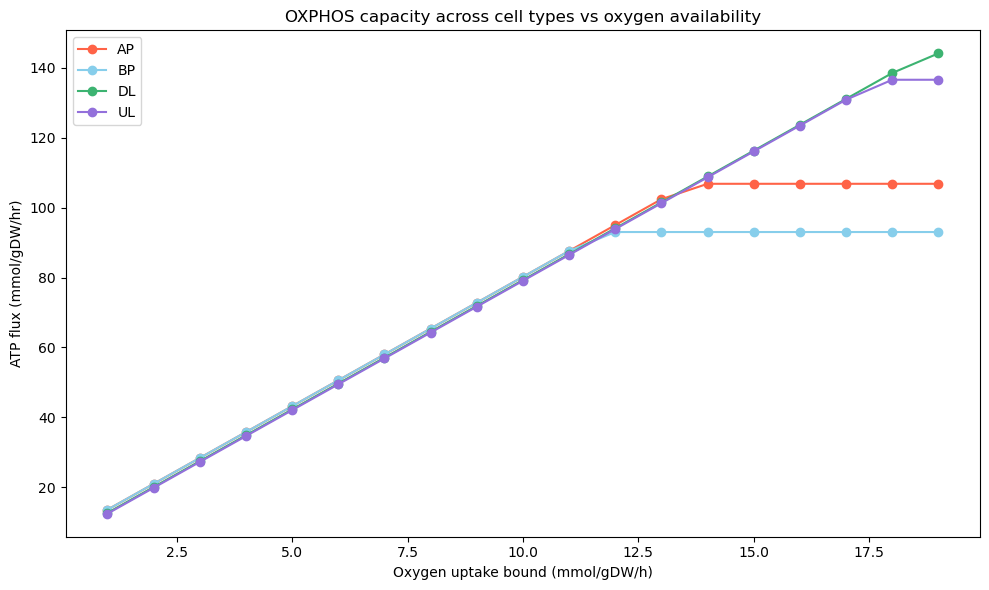

In [ ]:
import matplotlib.pyplot as plt

cell_types = {
    "AP": r"C:\Users\sacin\Downloads\mapped_AP_cycling_pseudobulk_normalized_sum.csv",
    "BP": r"C:\Users\sacin\Downloads\mapped_BP_cycling_pseudobulk_normalized_sum.csv",
    "DL": r"C:\Users\sacin\Downloads\mapped_DL_neurons_pseudobulk_normalized_sum.csv",
    "UL": r"C:\Users\sacin\Downloads\mapped_UL_differentiating_pseudobulk_normalized_sum.csv"
}

colors = {"AP": "tomato", "BP": "skyblue", "DL": "mediumseagreen", "UL": "mediumpurple"}

plt.figure(figsize=(10, 6))

for ct, filepath in cell_types.items():
    
    model = cobra.io.read_sbml_model(join(r"C:\Users\sacin\Downloads\Mitomammal_model_10.sbml"))
    list_of_genes = [gene.id for gene in model.genes]
    
    data_dictionary = read_csv_data(
        path=filepath,
        list_of_genes=list_of_genes,
        id_gene=0, id_val=7,
        sep=",", quantile=0.95, head=True)

    model.reactions.get_by_id("CII").bounds = (0.0, 1000)
    model.reactions.get_by_id("GLCt1r").bounds = (-1000, 5.0)
    model.reactions.get_by_id("r0942").bounds = (-0.05, 1000)
    model.reactions.get_by_id("r0942b_mitoMap").bounds = (-0.05, 1000)
    model.reactions.get_by_id("CK").bounds = (0.0, 1000.0)
    model.reactions.get_by_id("CKc").bounds = (0.0, 1000.0)
    model.reactions.get_by_id("FTHFLm").bounds = (0.0, 1000.0)

    model.objective = model.reactions[70]

    Eflux(model, data_dictionary, 1000, 1, ignore_human=True, ignore_mus=False)

    o2_values = []
    cv_values = []

    print(f"\n=== {ct} ===")
    for o2 in range(1, 20):
        model.reactions[478].upper_bound = o2
        model.reactions[478].lower_bound = 0
        sol = pfba(model)
        cv = sol.fluxes["CV_mitoMap"]
        o2_values.append(o2)
        cv_values.append(cv)
        print(f"O2 = {o2} | CV = {cv:.4f}")

    plt.plot(o2_values, cv_values, marker='o', label=ct, color=colors[ct])

plt.xlabel("Oxygen uptake bound (mmol/gDW/h)")
plt.ylabel("ATP flux (mmol/gDW/hr)")
plt.title("OXPHOS capacity across cell types vs oxygen availability")
plt.legend()
plt.tight_layout()
plt.savefig("oxygen_sweep.svg", format="svg")
plt.show()

In [ ]:
# get objective values (cytosolic ATP) for each cell type
AP_obj = result_AP_cyto[1].fluxes["OF_ATP_mitoMap"] - result_AP_cyto[1].fluxes["ATPtmB_mitoMap"]
BP_obj = result_BP_cyto[1].fluxes["OF_ATP_mitoMap"] - result_AP_cyto[1].fluxes["ATPtmB_mitoMap"]
DL_obj = result_DL_cyto[1].fluxes["OF_ATP_mitoMap"] - result_AP_cyto[1].fluxes["ATPtmB_mitoMap"]
UL_obj = result_UL_cyto[1].fluxes["OF_ATP_mitoMap"] - result_AP_cyto[1].fluxes["ATPtmB_mitoMap"]

# reactions to track
reactions = ["CV_mitoMap", "CI", "CII", "CIII", "CIV"]

# normalize each reaction flux by its own objective value
cell_types = ["AP", "BP", "DL", "UL"]
objectives = [AP_obj, BP_obj, DL_obj, UL_obj]
results_cyto = [result_AP_cyto[1], result_BP_cyto[1], result_DL_cyto[1], result_UL_cyto[1]]

print("Normalized fluxes (ATP flux (mmol/gDW/hr)):")
for i, ct in enumerate(cell_types):
    print(f"\n{ct} (objective = {objectives[i]:.3f})")
    for rxn in reactions:
        normalized = results_cyto[i].fluxes[rxn] / objectives[i]
        print(f"  {rxn}: {normalized:.4f}")

Normalized fluxes (flux / ATP objective):

AP (objective = 155.378)
  CV_mitoMap: 0.1825
  CI: 0.0386
  CII: 0.0000
  CIII: 0.0386
  CIV: 0.0193

BP (objective = 182.386)
  CV_mitoMap: 0.2774
  CI: 0.0658
  CII: 0.0000
  CIII: 0.0658
  CIV: 0.0329

DL (objective = 150.524)
  CV_mitoMap: 0.4776
  CI: 0.1196
  CII: 0.0000
  CIII: 0.1196
  CIV: 0.0598

UL (objective = 180.716)
  CV_mitoMap: 0.5195
  CI: 0.1328
  CII: 0.0000
  CIII: 0.1328
  CIV: 0.0664



CI
  AP: 0.0386
  BP: 0.0658
  DL: 0.1196
  UL: 0.1328

CII
  AP: 0.0000
  BP: 0.0000
  DL: 0.0000
  UL: 0.0000

CIII
  AP: 0.0386
  BP: 0.0658
  DL: 0.1196
  UL: 0.1328

CIV
  AP: 0.0193
  BP: 0.0329
  DL: 0.0598
  UL: 0.0664

CV_mitoMap
  AP: 0.1825
  BP: 0.2774
  DL: 0.4776
  UL: 0.5195


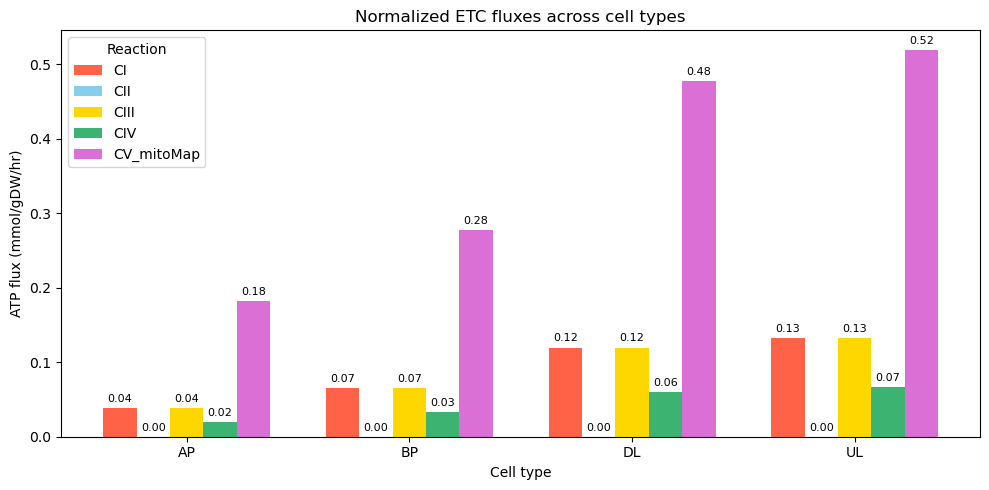

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

objectives = [
    result_AP_cyto[1].fluxes["OF_ATP_mitoMap"],
    result_BP_cyto[1].fluxes["OF_ATP_mitoMap"],
    result_DL_cyto[1].fluxes["OF_ATP_mitoMap"],
    result_UL_cyto[1].fluxes["OF_ATP_mitoMap"]
]

cell_types = ["AP", "BP", "DL", "UL"]
results_cyto = [
    result_AP_cyto[1],
    result_BP_cyto[1],
    result_DL_cyto[1],
    result_UL_cyto[1]
]

reactions = ["CI", "CII", "CIII", "CIV", "CV_mitoMap"]

# calculate normalized fluxes
normalized_fluxes = {}

for rxn in reactions:
    normalized_fluxes[rxn] = [
        results_cyto[i].fluxes[rxn] / objectives[i]
        for i in range(len(cell_types))
    ]

# print values
for rxn in reactions:
    print(f"\n{rxn}")
    for ct, val in zip(cell_types, normalized_fluxes[rxn]):
        print(f"  {ct}: {val:.4f}")

# plot
x = np.arange(len(cell_types))
width = 0.15

fig, ax = plt.subplots(figsize=(10, 5))

colors = ["tomato", "skyblue", "gold", "mediumseagreen", "orchid"]

for i, rxn in enumerate(reactions):
    bars = ax.bar(
        x + (i - 2) * width,
        normalized_fluxes[rxn],
        width,
        label=rxn,
        color=colors[i]
    )

    # add value labels
    for b in bars:
        height = b.get_height()
        ax.annotate(
            f"{height:.2f}",
            xy=(b.get_x() + b.get_width()/2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_xlabel("Cell type")
ax.set_ylabel("ATP flux (mmol/gDW/hr)")
ax.set_title("Normalized ETC fluxes across cell types")
ax.set_xticks(x)
ax.set_xticklabels(cell_types)
ax.legend(title="Reaction")

plt.tight_layout()
plt.show()

In [ ]:
for i, rxn in enumerate(model.reactions):
    if rxn.id in ['PGK', 'PYK', 'SUCOASm', 'CV_mitoMap']:
        print(f"{i}: {rxn.id}")

82: PGK
85: PYK
104: SUCOASm
107: CV_mitoMap


In [ ]:
print("AP fluxes:")
print(f"PGK: {result_AP_cyto[1].fluxes['PGK']:.2f}")
print(f"PYK: {result_AP_cyto[1].fluxes['PYK']:.2f}")
print(f"SUCOASm: {result_AP_cyto[1].fluxes['SUCOASm']:.2f}")
print(f"CV_mitoMap: {result_AP_cyto[1].fluxes['CV_mitoMap']:.2f}")

print("\nBP fluxes:")
print(f"PGK: {result_BP_cyto[1].fluxes['PGK']:.2f}")
print(f"PYK: {result_BP_cyto[1].fluxes['PYK']:.2f}")
print(f"SUCOASm: {result_BP_cyto[1].fluxes['SUCOASm']:.2f}")
print(f"CV_mitoMap: {result_BP_cyto[1].fluxes['CV_mitoMap']:.2f}")

print("\nDL fluxes:")
print(f"PGK: {result_DL_cyto[1].fluxes['PGK']:.2f}")
print(f"PYK: {result_DL_cyto[1].fluxes['PYK']:.2f}")
print(f"SUCOASm: {result_DL_cyto[1].fluxes['SUCOASm']:.2f}")
print(f"CV_mitoMap: {result_DL_cyto[1].fluxes['CV_mitoMap']:.2f}")

print("\nUL fluxes:")
print(f"PGK: {result_UL_cyto[1].fluxes['PGK']:.2f}")
print(f"PYK: {result_UL_cyto[1].fluxes['PYK']:.2f}")
print(f"SUCOASm: {result_UL_cyto[1].fluxes['SUCOASm']:.2f}")
print(f"CV_mitoMap: {result_UL_cyto[1].fluxes['CV_mitoMap']:.2f}")

AP fluxes:
PGK: -26.60
PYK: 26.60
SUCOASm: -106.50
CV_mitoMap: 28.36

BP fluxes:
PGK: -34.34
PYK: 34.34
SUCOASm: -98.80
CV_mitoMap: 50.59

DL fluxes:
PGK: -54.62
PYK: 54.62
SUCOASm: -24.02
CV_mitoMap: 71.89

UL fluxes:
PGK: -40.37
PYK: 40.37
SUCOASm: -46.46
CV_mitoMap: 93.88


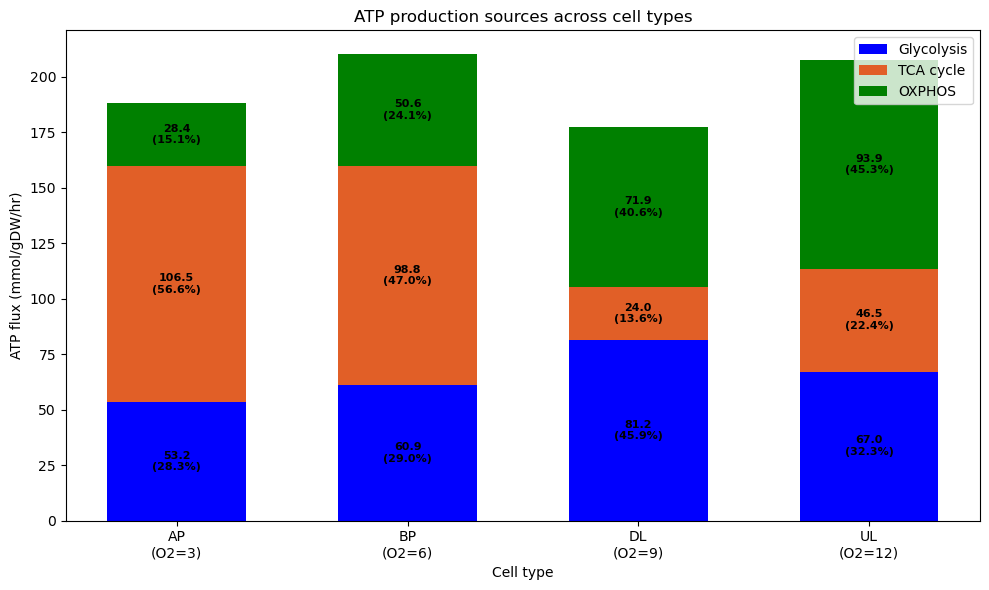

ATP flux breakdown:
AP
(O2=3): glyco=53.21 (28.3%), tca=106.50 (56.6%), oxphos=28.36 (15.1%), total=188.06
BP
(O2=6): glyco=60.94 (29.0%), tca=98.80 (47.0%), oxphos=50.59 (24.1%), total=210.33
DL
(O2=9): glyco=81.22 (45.9%), tca=24.02 (13.6%), oxphos=71.89 (40.6%), total=177.13
UL
(O2=12): glyco=66.98 (32.3%), tca=46.46 (22.4%), oxphos=93.88 (45.3%), total=207.32


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

glyco_ap = abs(result_AP_cyto[1].fluxes['PYK']+ abs(result_AP_cyto[1].fluxes['PGK']))
tca_ap = abs(result_AP_cyto[1].fluxes['SUCOASm'])
oxphos_ap = result_AP_cyto[1].fluxes['CV_mitoMap']

glyco_bp = abs(result_BP_cyto[1].fluxes['PYK'] + abs(result_AP_cyto[1].fluxes['PGK']))
tca_bp = abs(result_BP_cyto[1].fluxes['SUCOASm'])
oxphos_bp = result_BP_cyto[1].fluxes['CV_mitoMap']

glyco_dl = abs(result_DL_cyto[1].fluxes['PYK'] + abs(result_AP_cyto[1].fluxes['PGK']))
tca_dl = abs(result_DL_cyto[1].fluxes['SUCOASm'])
oxphos_dl = result_DL_cyto[1].fluxes['CV_mitoMap']

glyco_ul = abs(result_UL_cyto[1].fluxes['PYK'] + abs(result_AP_cyto[1].fluxes['PGK']))
tca_ul = abs(result_UL_cyto[1].fluxes['SUCOASm'])
oxphos_ul = result_UL_cyto[1].fluxes['CV_mitoMap']

cell_types = ["AP\n(O2=3)", "BP\n(O2=6)", "DL\n(O2=9)", "UL\n(O2=12)"]
glyco = [glyco_ap, glyco_bp, glyco_dl, glyco_ul]
tca = [tca_ap, tca_bp, tca_dl, tca_ul]
oxphos = [oxphos_ap, oxphos_bp, oxphos_dl, oxphos_ul]

totals = [glyco[i] + tca[i] + oxphos[i] for i in range(len(glyco))]
glyco_pct = [glyco[i]/totals[i]*100 for i in range(len(glyco))]
tca_pct = [tca[i]/totals[i]*100 for i in range(len(tca))]
oxphos_pct = [oxphos[i]/totals[i]*100 for i in range(len(oxphos))]

x = np.arange(len(cell_types))
width = 0.6

fig, ax = plt.subplots(figsize=(10, 6))
p1 = ax.bar(x, glyco, width, label='Glycolysis', color="light blue")
p2 = ax.bar(x, tca, width, bottom=glyco, label='TCA cycle', color="pink")
p3 = ax.bar(x, oxphos, width, bottom=np.array(glyco)+np.array(tca), label='OXPHOS', color="green")

ax.set_ylabel('ATP flux (mmol/gDW/hr)')
ax.set_xlabel('Cell type')
ax.set_title('ATP production sources across cell types')
ax.set_xticks(x)
ax.set_xticklabels(cell_types)
ax.legend()

for i in range(len(cell_types)):
    if glyco[i] > 0:
        ax.text(i, glyco[i]/2, f'{glyco[i]:.1f}\n({glyco_pct[i]:.1f}%)', ha='center', va='center', fontweight='bold', fontsize=8)
    if tca[i] > 0:
        ax.text(i, glyco[i] + tca[i]/2, f'{tca[i]:.1f}\n({tca_pct[i]:.1f}%)', ha='center', va='center', fontweight='bold', fontsize=8)
    if oxphos[i] > 0:
        ax.text(i, glyco[i] + tca[i] + oxphos[i]/2, f'{oxphos[i]:.1f}\n({oxphos_pct[i]:.1f}%)', ha='center', va='center', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.savefig('ATP_sources.png', dpi=300, bbox_inches='tight')
plt.show()

print("ATP flux breakdown:")
for i, ct in enumerate(cell_types):
    total = glyco[i] + tca[i] + oxphos[i]
    print(f"{ct}: glyco={glyco[i]:.2f} ({glyco_pct[i]:.1f}%), tca={tca[i]:.2f} ({tca_pct[i]:.1f}%), oxphos={oxphos[i]:.2f} ({oxphos_pct[i]:.1f}%), total={total:.2f}")